In [16]:
from pathlib import Path
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
# Directory containing the CSV files
data_dir = Path("/home/jolivera/Documents/CloudSkin/Time-Series-Library/dataset_paper_joan")

# Collect all CSV files
csv_paths = sorted(data_dir.glob("*.csv"))
latency_frames = []

for path in csv_paths:
    df = pd.read_csv(path)

    # Ensure expected columns exist
    expected_cols = {"timestamp", "metric", "value", "unit"}
    if not expected_cols.issubset(df.columns):
        continue

    # Keep only latency rows (metric ends with ".latency")
    mask = df["metric"].astype(str).str.endswith(".latency", na=False)
    df_lat = df.loc[mask].copy()
    if df_lat.empty:
        continue

    # Extract pipeline_id from "metric" (format: pipeline_id.row_type)
    df_lat["pipeline_id"] = df_lat["metric"].astype(str).str.rsplit(".", n=3).str[2]
    df_lat.drop(columns=['metric'], inplace=True)
    df_lat.rename(columns={'value':'latency'}, inplace=True)    

    latency_frames.append(df_lat)

In [3]:
latency_frames[0]

,timestamp,latency,unit,pipeline_id
1,1.773134e+09,644.79,ms,284c58181c6111f1a3ee0e6180d51d27
3,1.773134e+09,96.76,ms,284c58181c6111f1a3ee0e6180d51d27
5,1.773134e+09,108.88,ms,284c58181c6111f1a3ee0e6180d51d27
7,1.773134e+09,130.29,ms,284c58181c6111f1a3ee0e6180d51d27
9,1.773134e+09,123.53,ms,284c58181c6111f1a3ee0e6180d51d27
...,...,...,...,...
84075,1.773135e+09,152.27,ms,40c2d5641c6311f1a3ee0e6180d51d27
84077,1.773135e+09,117.66,ms,40c2d5641c6311f1a3ee0e6180d51d27
84079,1.773135e+09,139.81,ms,40c2d5641c6311f1a3ee0e6180d51d27
84081,1.773135e+09,143.62,ms,40c2d5641c6311f1a3ee0e6180d51d27


In [4]:
# Combine all latency data into a single DataFrame
if latency_frames:
    all_latency = pd.concat(latency_frames, ignore_index=True)
else:
    all_latency = pd.DataFrame(columns=["timestamp", "latency", "unit", "pipeline_id"])

# Parse timestamps and sort
all_latency["timestamp"] = pd.to_datetime(all_latency["timestamp"],unit='s', utc=True, errors="coerce")
all_latency = all_latency.dropna(subset=["timestamp"])
all_latency = all_latency.sort_values("timestamp").reset_index(drop=True)

# If there is no data, just display the empty frame
if all_latency.empty:
    display(all_latency)
else:
    # Prepare arrays for sliding-window computation
    timestamps = all_latency["timestamp"].to_numpy("datetime64[ns]").astype("int64")
    pipelines = all_latency["pipeline_id"].to_numpy()

    # 1-second trailing window in nanoseconds
    window_ns = 5 * 1_000_000_000
    active_counts = np.empty(len(all_latency), dtype=int)

    left = 0
    right = 0
    counts = Counter()

    for left in range(len(all_latency)):
        # Extend right so that [left, right-1] is the window [t_left, t_left+10s]
        while right < len(all_latency) and timestamps[right] <= timestamps[left] + window_ns:
            counts[pipelines[right]] += 1
            right += 1
        # Require recent activity: only count pipelines with >= 2 events in the window (excludes stragglers)
        #active_counts[left] = sum(1 for c in counts.values() if c >= 2)
        active_counts[left] = len(counts)
        # Remove current row from window and advance
        counts[pipelines[left]] -= 1
        if counts[pipelines[left]] == 0:
            del counts[pipelines[left]]

    # New column: concurrent pipelines in the next 10 seconds (forward window)
    all_latency["concurrent_pipelines"] = active_counts


    # Optionally, write final result to CSV
    output_path = data_dir / "data_cleaned.csv"
    all_latency.to_csv(output_path, index=False)

    # Show a preview
    display(all_latency.head())

,timestamp,latency,unit,pipeline_id,concurrent_pipelines
0,2026-03-05 17:15:52.779434919+00:00,659.10,ms,f56963f818b611f1ba10328830565611,1
1,2026-03-05 17:15:52.808205843+00:00,100.98,ms,f56963f818b611f1ba10328830565611,1
2,2026-03-05 17:15:52.808465481+00:00,90.12,ms,f56963f818b611f1ba10328830565611,1
3,2026-03-05 17:15:52.822306395+00:00,97.02,ms,f56963f818b611f1ba10328830565611,1
4,2026-03-05 17:15:52.883364201+00:00,148.45,ms,f56963f818b611f1ba10328830565611,1


<Axes: >

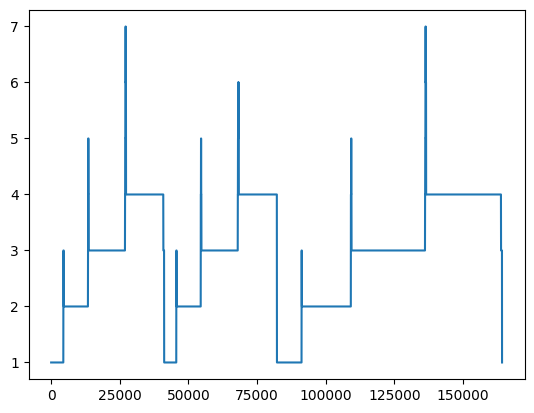

In [5]:
all_latency.concurrent_pipelines.plot()

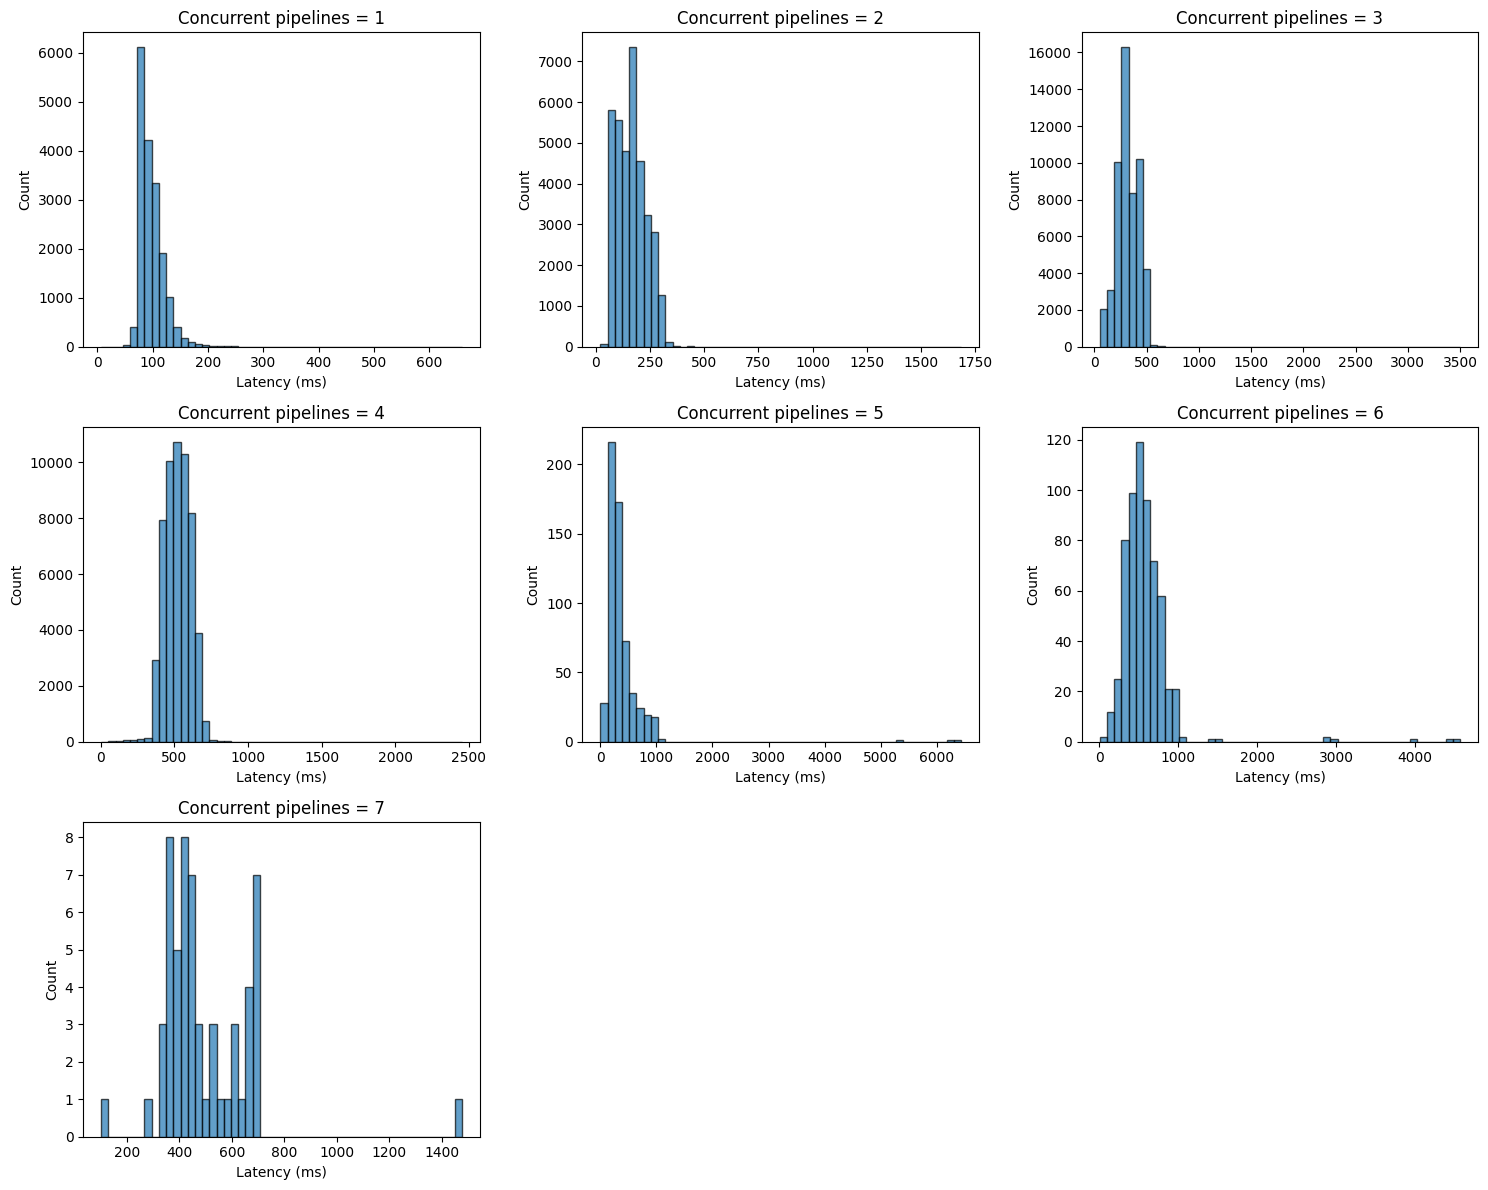

In [6]:
# Latency distribution: one subplot per number of concurrent pipelines
concurrency_levels = sorted(all_latency["concurrent_pipelines"].unique())
n_levels = len(concurrency_levels)
if n_levels == 0:
    print("No data to plot")
else:
    n_cols = min(3, n_levels)
    n_rows = (n_levels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_levels == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    for i, level in enumerate(concurrency_levels):
        ax = axes[i]
        data = all_latency.loc[all_latency["concurrent_pipelines"] == level, "latency"]
        ax.hist(data, bins=50, edgecolor="black", alpha=0.7)
        ax.set_title(f"Concurrent pipelines = {level}")
        ax.set_xlabel("Latency (ms)")
        ax.set_ylabel("Count")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

In [7]:
all_latency.concurrent_pipelines.value_counts()

concurrent_pipelines
4    55181
3    54349
2    35602
1    17832
6      615
5      591
7       58
Name: count, dtype: int64

Treat them as cold start (which they are). We check if before and after the number of pipelines change and exclude those values.

In [14]:
# Detect pipeline-count transitions (shut all + restart) and mark cold-start windows to exclude.
# We bucket time and compare pipeline_id sets; when they change drastically, that's a transition.

bucket_sec = 10  # coarse window to get a stable "current" set of pipelines per period
jaccard_threshold = 0.7  # consecutive buckets with overlap below this → transition
exclude_before_sec = 5   # seconds before transition to exclude
exclude_after_sec = 25   # seconds after transition (cold start) to exclude

ts_sec = all_latency["timestamp"].astype("int64") // 1_000_000_000
all_latency["_bucket"] = (ts_sec - ts_sec.min()) // bucket_sec

# Set of pipeline_ids per bucket (pipelines that appear in that time bucket)
bucket_sets = all_latency.groupby("_bucket")["pipeline_id"].apply(lambda x: set(x.unique())).to_dict()
buckets_sorted = sorted(bucket_sets.keys())

transition_bucket_starts = []
for i in range(len(buckets_sorted) - 1):
    b0, b1 = buckets_sorted[i], buckets_sorted[i + 1]
    s0, s1 = bucket_sets[b0], bucket_sets[b1]
    if not s0 or not s1:
        continue
    inter = len(s0 & s1)
    union = len(s0 | s1)
    jaccard = inter / union if union else 0
    if jaccard < jaccard_threshold:
        # transition: new bucket starts at time corresponding to b1
        t_start_sec = ts_sec.min() + b1 * bucket_sec
        transition_bucket_starts.append(t_start_sec)

# Build cold-start mask: True if timestamp falls in [T - exclude_before, T + exclude_after] for any transition T
ts_ns = all_latency["timestamp"].astype("int64")
cold_start = np.zeros(len(all_latency), dtype=bool)
for T_sec in transition_bucket_starts:
    T_ns = T_sec * 1_000_000_000
    lo = T_ns - exclude_before_sec * 1_000_000_000
    hi = T_ns + exclude_after_sec * 1_000_000_000
    cold_start |= (ts_ns >= lo) & (ts_ns <= hi)

all_latency["cold_start"] = cold_start
all_latency.drop(columns=["_bucket"], inplace=True)

# Filtered dataframe without cold-start points (use this for latency analysis)
all_latency_warm = all_latency[~all_latency["cold_start"]].copy()

print(f"Detected {len(transition_bucket_starts)} transitions. Excluded {cold_start.sum()} rows as cold start ({100 * cold_start.mean():.1f}%).")
print(f"all_latency_warm has {len(all_latency_warm)} rows.")

Detected 20 transitions. Excluded 14513 rows as cold start (8.8%).
all_latency_warm has 149715 rows.


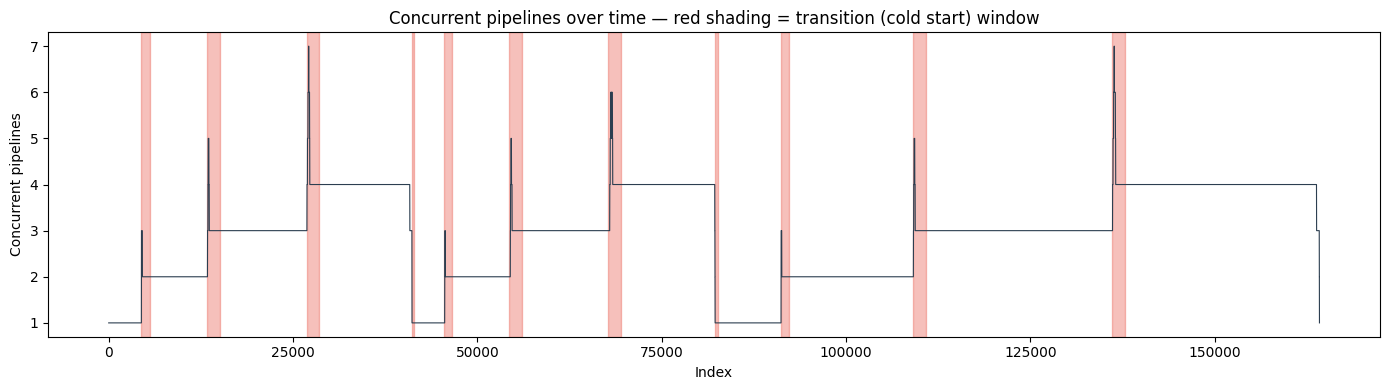

In [20]:
# Concurrent pipelines vs index (warm data only — cold start excluded)
fig, ax = plt.subplots(figsize=(14, 4))
n = len(all_latency)

# Shade index ranges where cold_start is True
cold = all_latency["cold_start"].to_numpy()
i = 0
while i < n:
    if cold[i]:
        j = i
        while j < n and cold[j]:
            j += 1
        ax.axvspan(i, j - 1, color="#e74c3c", alpha=0.35)
        i = j
    else:
        i += 1

# Line plot: concurrent_pipelines by index
all_latency["concurrent_pipelines"].plot(ax=ax, color="#2c3e50", linewidth=0.8)
ax.set_xlabel("Index")
ax.set_ylabel("Concurrent pipelines")
ax.set_title("Concurrent pipelines over time — red shading = transition (cold start) window")
plt.tight_layout()
plt.show()

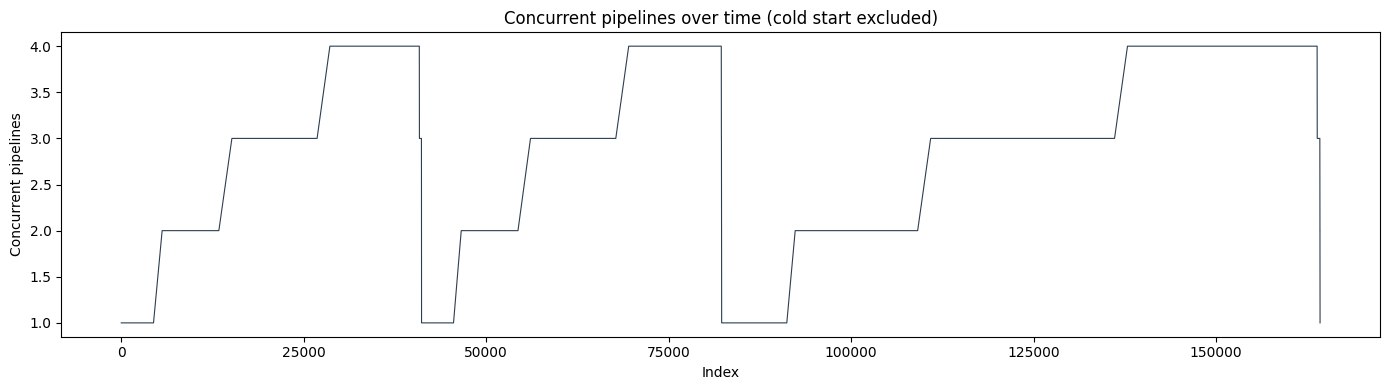

In [21]:
# Concurrent pipelines vs index (warm data only — cold start excluded)
fig, ax = plt.subplots(figsize=(14, 4))
all_latency_warm["concurrent_pipelines"].plot(ax=ax, color="#2c3e50", linewidth=0.8)
ax.set_xlabel("Index")
ax.set_ylabel("Concurrent pipelines")
ax.set_title("Concurrent pipelines over time (cold start excluded)")
plt.tight_layout()
plt.show()

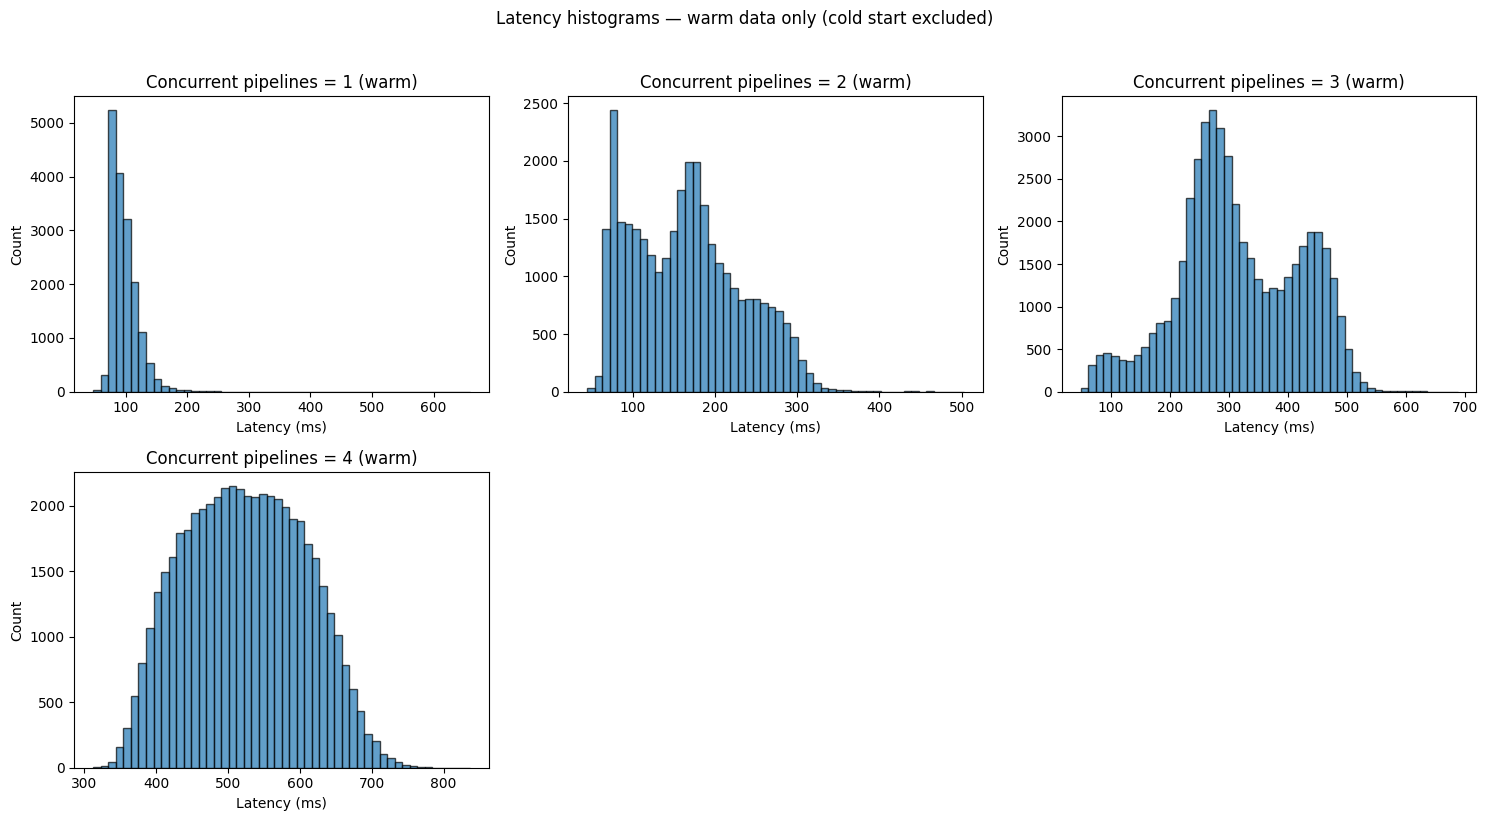

In [17]:
# Latency distribution: warm data only (cold-start points masked out)
warm = all_latency_warm
concurrency_levels = sorted(warm["concurrent_pipelines"].unique())
n_levels = len(concurrency_levels)
if n_levels == 0:
    print("No warm data to plot")
else:
    n_cols = min(3, n_levels)
    n_rows = (n_levels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_levels == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    for i, level in enumerate(concurrency_levels):
        ax = axes[i]
        data = warm.loc[warm["concurrent_pipelines"] == level, "latency"]
        ax.hist(data, bins=50, edgecolor="black", alpha=0.7)
        ax.set_title(f"Concurrent pipelines = {level} (warm)")
        ax.set_xlabel("Latency (ms)")
        ax.set_ylabel("Count")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Latency histograms — warm data only (cold start excluded)", y=1.02)
    plt.tight_layout()
    plt.show()

In [18]:
# Latency metrics by concurrency (warm data) — for overhead evaluation
metrics = all_latency_warm.groupby("concurrent_pipelines")["latency"].agg(
    count="count",
    mean_ms="mean",
    median_ms="median",
    std_ms="std",
    min_ms="min",
    max_ms="max",
    p90_ms=lambda x: x.quantile(0.90),
    p95_ms=lambda x: x.quantile(0.95),
    p99_ms=lambda x: x.quantile(0.99),
).round(2)
metrics

,count,mean_ms,median_ms,std_ms,min_ms,max_ms,p90_ms,p95_ms,p99_ms
concurrent_pipelines,,,,,,,,,
1,17072,97.51,92.44,22.17,47.15,659.10,124.99,136.33,169.12
2,32409,165.28,163.77,66.61,44.66,502.59,263.07,283.83,311.33
3,49281,315.28,299.93,101.79,49.66,687.74,457.59,476.96,507.67
4,50953,523.85,522.67,82.77,312.63,836.67,634.56,658.40,698.22
